
# Notebook 01 — Couche de données : de l'export Excel à SQL, puis à Spark

**Copilote Financier — Groupe Angelotti | Mémoire M2 MIASHS**

Ce notebook documente la **couche d'ingestion** du Copilote : comment les
4 exports Excel du logiciel de gestion deviennent une base SQL propre et
interrogeable (`data/copilote.db`), et comment cette même préparation
passerait à l'échelle avec **PySpark** si la volumétrie l'exigeait.

Il mobilise deux modules du master : **Bases de données SQL** et **Données
massives / parallélisation**. Contrairement aux autres notebooks, ces deux
modules **ne disposent pas de support PDF dans le dossier `Cours/`** du
dépôt (voir `docs/reference_cours.md`, construit sur les 9 PDF disponibles) ;
nous suivons donc la **terminologie standard** du domaine : algèbre
relationnelle et modèle relationnel (Codd, 1970 ; norme ISO/IEC 9075 pour
SQL), paradigme **MapReduce** (Dean & Ghemawat, 2008) et **RDD / Spark**
(Zaharia *et al.*, 2012).

Plan : (1) rappel du pipeline et du schéma en étoile ; (2) requêtes SQL de
complexité croissante sur la base ; (3) démonstration Spark — paresse,
agrégation distribuée, MapReduce — et comparaison **honnête** avec pandas
sur notre volumétrie ; (4) synthèse pour les trois axes du copilote.


In [1]:
# --- Amorçage : exécution locale ou Google Colab ---
import importlib.util, pathlib, subprocess, sys

DEPOT = "github.com/yzasmin/MemoireM2S2.git"
BRANCHE = "claude/copilote-financier-angelotti-72c614"

racine = pathlib.Path.cwd()
while not (racine / "src" / "nettoyage.py").exists() and racine != racine.parent:
    racine = racine.parent
if not (racine / "src" / "nettoyage.py").exists():   # environnement Colab vierge
    r = subprocess.run(["git", "clone", "-b", BRANCHE, f"https://{DEPOT}"],
                       capture_output=True, text=True)
    if r.returncode != 0:                             # dépôt privé -> token requis
        from getpass import getpass
        token = getpass("Dépôt privé — colle un token GitHub en LECTURE SEULE : ").strip()
        subprocess.run(["git", "clone", "-b", BRANCHE, f"https://{token}@{DEPOT}"],
                       check=True)
    racine = pathlib.Path.cwd() / "MemoireM2S2"
    # N'installe que ce qui manque (Colab a déjà pandas/sklearn/statsmodels)
    for module, paquet in [("openpyxl", "openpyxl"), ("networkx", "networkx"),
                           ("statsmodels", "statsmodels"), ("sklearn", "scikit-learn")]:
        if importlib.util.find_spec(module) is None:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", paquet],
                           check=True)

sys.path.insert(0, str(racine / "src"))
import base_sql

if not base_sql.DB.exists():  # reconstruit data/copilote.db depuis donnéebrut/
    base_sql.construire_base()
DB = base_sql.DB
print("Base prête :", DB)


Base prête : /home/user/MemoireM2S2/data/copilote.db



## 1. Le pipeline d'ingestion et le schéma en étoile

Deux modules Python construisent la base (aucune retouche manuelle des
fichiers, tout est rejouable) :

- `src/nettoyage.py` — lit les 4 exports Excel de `donnéebrut/`, corrige les
  pièges identifiés à l'exploration (fichier « Informations Lots » limité aux
  désistements, valeurs sentinelles à 0, libellés hétérogènes, communes en
  double orthographe) et produit 7 tables propres ;
- `src/base_sql.py` — charge ces tables dans SQLite, pose les index sur les
  clés de jointure et définit 3 **vues métier** en SQL pur.

Le schéma suit une organisation **en étoile** : des tables de **faits** au
grain fin (lignes budgétaires, lots, dossiers de vente) reliées à des tables
de **dimensions** (opérations, communes, conjoncture) par des clés simples.

```text
donnéebrut/*.xlsx ──> src/nettoyage.py ──> src/base_sql.py ──> data/copilote.db

        FAITS                        DIMENSIONS
  budget (64 788) ──┐
  lots (14 123) ────┤ id_operation   operations (267)
  ventes (14 428) ──┤                     │ commune_norm
  desistements ─────┘                     ▼
   (2 164)                           communes (90)

  ventes.date_reservation ──strftime('%Y-%m')──> conjoncture.mois (138)

  vues SQL : v_marge_operation | v_ecoulement_mensuel | v_stock_lots
```

Clés de jointure (voir `docs/02_dictionnaire_donnees.md`) : `id_operation`
relie toutes les tables internes ; `commune_norm` (nom normalisé, 91
orthographes → 90 communes) relie les opérations au référentiel externe ;
le mois `YYYY-MM` relie les ventes à la conjoncture macroéconomique.


In [2]:

import sqlite3
import pandas as pd

import theme_viz
theme_viz.appliquer()

con = sqlite3.connect(DB)
inventaire = pd.read_sql("""
    SELECT name AS objet, type
    FROM sqlite_master
    WHERE type IN ('table', 'view') AND name NOT LIKE 'sqlite_%'
    ORDER BY type DESC, name
""", con)
inventaire["lignes"] = [con.execute(f'SELECT COUNT(*) FROM "{n}"').fetchone()[0]
                        for n in inventaire["objet"]]
inventaire


,objet,type,lignes
0,v_ecoulement_mensuel,view,1627
1,v_marge_operation,view,267
2,v_stock_lots,view,196
3,budget,table,64788
4,communes,table,90
5,conjoncture,table,138
6,desistements,table,2164
7,lots,table,14123
8,operations,table,267
9,ventes,table,14428



**Lecture.** La base contient bien les 7 tables du dictionnaire de données
et les 3 vues métier. Le catalogue `sqlite_master` est lui-même interrogeable
en SQL : la base se décrit elle-même, premier avantage sur une collection de
fichiers Excel.

## 2. Le module SQL en action : cinq requêtes de complexité croissante

SQL est un langage **déclaratif** : on décrit le résultat voulu, le moteur
choisit le plan d'exécution (ordre des jointures, usage des index). Nous
déroulons les opérateurs de l'algèbre relationnelle (Codd, 1970) du plus
simple au plus riche : sélection/projection, jointure, agrégation avec
`HAVING`, vue avec `CASE WHEN`, puis fonction **fenêtre**. Chaque requête
répond à une vraie question métier du copilote, et `pandas.read_sql` sert de
pont vers l'écosystème Python des notebooks suivants.

### 2.1 Sélection et projection

La **sélection** $\sigma$ (clause `WHERE`) filtre les lignes ; la
**projection** $\pi$ (liste du `SELECT`) ne garde que les colonnes utiles.
Question métier : quelles opérations sont en cours à l'agence de
Montpellier ?


In [3]:

q_projection = """
    SELECT libelle, agence, statut, commune          -- projection (pi)
    FROM operations
    WHERE statut = 'En Cours'                        -- sélection (sigma)
      AND agence LIKE '%Montpellier%'
    ORDER BY commune, libelle
    LIMIT 8
"""
pd.read_sql(q_projection, con)


,libelle,agence,statut,commune
0,LE CLOS DES AMANDIERS,AMENAGEMENT / Agence Montpellier,En Cours,AUBAIS
1,LE MAS BERNICE,AMENAGEMENT / Agence Montpellier,En Cours,BERNIS
2,DP LE CLOS DE PROVENCE,AMENAGEMENT / Agence Montpellier,En Cours,BOUILLARGUES
3,LE BELVEDERE,AMENAGEMENT / Agence Montpellier,En Cours,COMPS
4,LES JARDINS D'HELIOS ML226,Agence Montpellier,En Cours,COURNONTERRAL
5,LES AIRES VIEILLES SUD,AMENAGEMENT / Agence Montpellier,En Cours,DOMAZAN
6,LE CLOS DES VIGNES,AMENAGEMENT / Agence Montpellier,En Cours,ESTEZARGUES
7,LOUS CROZES,AMENAGEMENT / Agence Montpellier,En Cours,GALARGUES



**Lecture.** La requête ne rapatrie que 4 colonnes sur 13 et 8 lignes sur
267 : filtrer **dans** la base plutôt qu'en mémoire est le premier réflexe
d'économie — décisif quand la table fait des millions de lignes (section 3).

### 2.2 Jointure : croiser la gestion interne et le référentiel externe

La **jointure** d'équivalence relie chaque opération à sa commune
(`ON o.commune_norm = c.commune_norm`) et rapatrie population et distance au
littoral, absentes des exports internes. C'est la normalisation des
orthographes faite dans `src/nettoyage.py` qui rend cette clé fiable.


In [4]:

q_jointure = """
    SELECT o.libelle, o.statut, c.nom_insee, c.departement,
           c.population, c.littoral
    FROM operations o
    JOIN communes c ON o.commune_norm = c.commune_norm
    WHERE o.statut = 'En Cours'
    ORDER BY c.population DESC
    LIMIT 8
"""
pd.read_sql(q_jointure, con)


,libelle,statut,nom_insee,departement,population,littoral
0,SPORTING FACTORY,En Cours,Toulouse,31,514819.0,0
1,NATURE & SENS,En Cours,Toulouse,31,514819.0,0
2,SKY LODGE,En Cours,Montpellier,34,310240.0,0
3,COSY LODGE,En Cours,Montpellier,34,310240.0,0
4,LE JOYAU DE L'AIGUELONGUE,En Cours,Montpellier,34,310240.0,0
5,HAMEAU DES TROIS PONTS,En Cours,Nîmes,30,151839.0,0
6,VERTEFEUILLE CPI,En Cours,Perpignan,66,121616.0,0
7,SOLIGREEN,En Cours,Béziers,34,81545.0,0



**Lecture.** Les opérations en cours dans les plus grandes communes
(Toulouse, Montpellier) sortent en tête ; l'indicateur `littoral` distingue
déjà deux marchés (résidence principale vs secondaire) que l'axe C
exploitera comme variable hédonique.

### 2.3 Agrégation : `GROUP BY` et `HAVING`

L'agrégation réduit le grain : de la ligne budgétaire (64 788) à la commune.
`WHERE` filtre **avant** agrégation (on ne garde que les recettes,
`sens = 'R'`), `HAVING` filtre **après** (on ne garde que les communes qui
pèsent plus de 50 M€ de chiffre d'affaires budgété) — c'est la distinction
classique entre les deux clauses.


In [5]:

q_havg = """
    SELECT o.commune_norm,
           COUNT(DISTINCT o.id_operation)   AS nb_operations,
           ROUND(SUM(b.budget_ht) / 1e6, 1) AS ca_budgete_meur
    FROM operations o
    JOIN budget b USING (id_operation)
    WHERE b.sens = 'R'                       -- avant agrégation
    GROUP BY o.commune_norm
    HAVING SUM(b.budget_ht) > 50e6           -- après agrégation
    ORDER BY ca_budgete_meur DESC
"""
top_communes = pd.read_sql(q_havg, con)
top_communes


,commune_norm,nb_operations,ca_budgete_meur
0,BEZIERS,31,230.2
1,CANET EN ROUSSILLON,19,188.5
2,LE CAP D AGDE,2,117.1
3,MONTPELLIER,8,99.9
4,TOULOUSE,6,84.8
5,VIAS,10,70.5
6,MARSEILLAN,12,67.2
7,PERTUIS,12,64.2
8,SERIGNAN,6,61.8
9,SAUVIAN,9,52.7


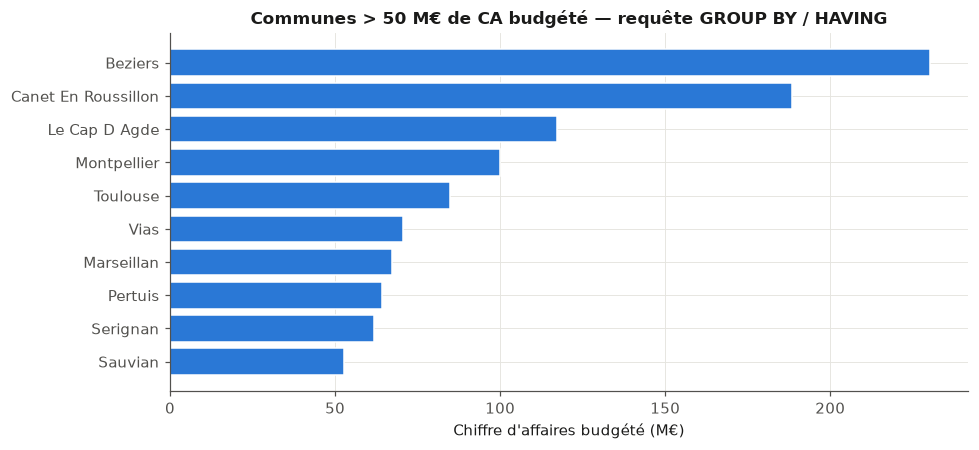

In [6]:

import matplotlib.pyplot as plt

d = top_communes.sort_values("ca_budgete_meur")
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(d["commune_norm"].str.title(), d["ca_budgete_meur"],
        color=theme_viz.SERIES[0], edgecolor="white")
ax.set_xlabel("Chiffre d'affaires budgété (M€)")
ax.set_title("Communes > 50 M€ de CA budgété — requête GROUP BY / HAVING")
plt.tight_layout()
plt.show()



**Lecture.** Le portefeuille est concentré sur le littoral occitan : Béziers
(31 opérations) et Canet-en-Roussillon dominent, et Le Cap d'Agde atteint
117 M€ avec 2 opérations seulement — des programmes exceptionnellement gros
dont le poids devra être surveillé dans les modèles de l'axe A (une seule
opération peut faire basculer un agrégat).

### 2.4 Vue métier : `v_marge_operation` et le `CASE WHEN`

Une **vue** est une requête nommée stockée dans le catalogue : elle
s'interroge comme une table mais reste toujours synchrone avec les données
sources. `v_marge_operation` (définie dans `src/base_sql.py`) pivote le sens
comptable Dépenses/Recettes grâce à l'agrégation conditionnelle
`SUM(CASE WHEN ... THEN ... ELSE ... END)` et protège la division du taux
d'engagement contre les budgets nuls. Affichons sa définition telle que
stockée dans la base, puis utilisons-la.


In [7]:

print(pd.read_sql(
    "SELECT sql FROM sqlite_master WHERE name = 'v_marge_operation'", con
).iloc[0, 0])


CREATE VIEW v_marge_operation AS
        SELECT
            o.id_operation,
            o.libelle,
            o.agence,
            o.statut,
            o.commune_norm,
            SUM(CASE WHEN b.sens = 'R' THEN b.budget_ht  ELSE 0 END) AS recettes_budget,
            SUM(CASE WHEN b.sens = 'D' THEN b.budget_ht  ELSE 0 END) AS depenses_budget,
            SUM(CASE WHEN b.sens = 'R' THEN b.facture_ht ELSE 0 END) AS recettes_facturees,
            SUM(CASE WHEN b.sens = 'D' THEN b.engage_ht  ELSE 0 END) AS depenses_engagees,
            SUM(CASE WHEN b.sens = 'D' THEN b.facture_ht ELSE 0 END) AS depenses_facturees,
            SUM(CASE WHEN b.sens = 'R' THEN b.budget_ht  ELSE -b.budget_ht END) AS marge_budget,
            CASE WHEN SUM(CASE WHEN b.sens = 'D' THEN b.budget_ht ELSE 0 END) > 0
                 THEN SUM(CASE WHEN b.sens = 'D' THEN b.engage_ht ELSE 0 END)
                      / SUM(CASE WHEN b.sens = 'D' THEN b.budget_ht ELSE 0 END)
            END AS taux_engagement
    

In [8]:

q_vue = """
    SELECT libelle, statut,
           ROUND(recettes_budget / 1e6, 1)  AS recettes_meur,
           ROUND(depenses_budget / 1e6, 1)  AS depenses_meur,
           ROUND(marge_budget / 1e6, 1)     AS marge_meur,
           ROUND(100.0 * marge_budget / recettes_budget, 1) AS marge_pct,
           ROUND(100.0 * taux_engagement, 0) AS engagement_pct
    FROM v_marge_operation
    WHERE recettes_budget > 0
    ORDER BY marge_meur DESC
    LIMIT 8
"""
pd.read_sql(q_vue, con)


,libelle,statut,recettes_meur,depenses_meur,marge_meur,marge_pct,engagement_pct
0,COMBES+LONJON+ROCHE,En étude,18.7,5.7,13.1,69.8,28.0
1,ILA,En étude,64.0,57.8,6.2,9.7,3.0
2,Allée du Comminges,En étude,9.6,3.6,6.0,62.7,8.0
3,ZAC SAINT-MARTIN,En étude,20.3,14.8,5.5,27.1,0.0
4,ZAC LES MONTARELS,En étude,17.5,12.9,4.6,26.2,12.0
5,BLEU ODYSSEE,En Cours,25.0,20.8,4.3,17.1,100.0
6,BLEU HORIZON,En Cours,32.6,28.5,4.1,12.5,100.0
7,ROC DE MAJORQUE,En étude,7.8,3.7,4.1,52.8,0.0



**Lecture.** La vue livre en une requête le socle de l'**axe A** : marge
budgétée et taux d'engagement par opération. Encapsuler ce calcul en SQL
garantit que les notebooks 00, 03 et la plateforme finale partagent
exactement la même définition de la marge — une seule source de vérité,
plutôt qu'un calcul recopié (et divergent) dans chaque fichier.

### 2.5 Fonction fenêtre : l'écoulement cumulé par opération

Les **fonctions fenêtre** (SQL:2003) calculent un agrégat *sans réduire le
grain* : chaque ligne reçoit une valeur calculée sur sa « fenêtre ». Ici,
`SUM(nb_reservations) OVER (PARTITION BY id_operation ORDER BY mois)`
découpe les lignes de `v_ecoulement_mensuel` par opération, les ordonne par
mois, et cumule du début jusqu'à la ligne courante (cadre par défaut) : on
obtient la **courbe d'écoulement cumulée**, l'objet central de l'axe B.


In [9]:

q_fenetre = """
    SELECT e.id_operation, o.libelle, e.mois, e.nb_reservations,
           SUM(e.nb_reservations) OVER (
               PARTITION BY e.id_operation ORDER BY e.mois
           ) AS cumul_reservations
    FROM v_ecoulement_mensuel e
    JOIN operations o USING (id_operation)
"""
ecoulement = pd.read_sql(q_fenetre, con)
# Extrait : les 10 premiers mois de la plus grosse opération en volume
id_max = ecoulement.groupby("id_operation")["nb_reservations"].sum().idxmax()
ecoulement.query("id_operation == @id_max").head(10)


,id_operation,libelle,mois,nb_reservations,cumul_reservations
723,62,LE VIBES RESORT,2019-12,1,1
724,62,LE VIBES RESORT,2020-01,1,2
725,62,LE VIBES RESORT,2020-05,2,4
726,62,LE VIBES RESORT,2020-06,3,7
727,62,LE VIBES RESORT,2020-07,3,10
728,62,LE VIBES RESORT,2020-08,3,13
729,62,LE VIBES RESORT,2021-04,3,16
730,62,LE VIBES RESORT,2021-08,3,19
731,62,LE VIBES RESORT,2021-09,3,22
732,62,LE VIBES RESORT,2021-11,21,43


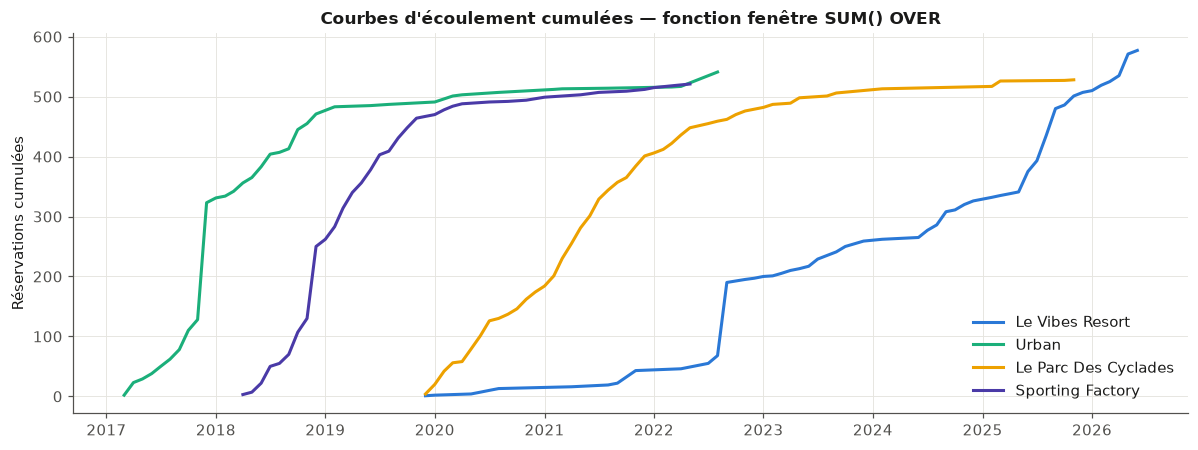

In [10]:

top4 = (ecoulement.groupby("id_operation")["nb_reservations"]
        .sum().nlargest(4).index)
fig, ax = plt.subplots(figsize=(11, 4.2))
for i, op in enumerate(top4):
    d = ecoulement[ecoulement["id_operation"] == op].sort_values("mois")
    ax.plot(pd.to_datetime(d["mois"]), d["cumul_reservations"],
            color=theme_viz.SERIES[i], label=d["libelle"].iloc[0].title())
ax.set_ylabel("Réservations cumulées")
ax.set_title("Courbes d'écoulement cumulées — fonction fenêtre SUM() OVER")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()



**Lecture.** Les quatre plus grosses opérations montrent des profils
d'écoulement très différents : démarrages en flèche (bonne adéquation
prix/marché au lancement) contre montées lentes avec paliers (pauses
commerciales, files de désistements). Modéliser la **pente** de ces courbes
et sa sensibilité à la conjoncture est exactement l'objet du notebook 04.

## 3. Le module données massives : la même préparation, en Spark

SQLite traite nos 64 788 lignes budgétaires sans effort, mais que se
passerait-il si le groupe consolidait des centaines de promoteurs, ou des
flux transactionnels bancaires ? **Apache Spark** répond en distribuant les
données en **partitions** traitées en parallèle par plusieurs exécuteurs,
selon l'héritage de MapReduce (Dean & Ghemawat, 2008) généralisé par les
RDD (Zaharia *et al.*, 2012). Nous reproduisons l'agrégation budgétaire de
la section 2 en PySpark, puis nous mesurons honnêtement ce que cela coûte à
notre échelle.

### 3.1 Installation et session locale

Spark s'exécute dans une JVM (Java 21 disponible ici) ; le mode
`local[*]` simule un cluster en utilisant tous les cœurs de la machine —
même code, même plan d'exécution qu'en production distribuée, seul le
gestionnaire de ressources change.


In [11]:

import os
import time

try:
    import pyspark
except ModuleNotFoundError:  # installation à la volée si absent
    # --use-pep517 force un environnement de build isolé (le setuptools
    # système de certaines distributions fait échouer le build classique).
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "--use-pep517", "pyspark"], check=True)
    import pyspark

# Réglages propres à l'infrastructure d'exécution : on neutralise une
# option Java du proxy local (bavarde au démarrage de la JVM, sans objet
# pour Spark en local) et on fixe l'adresse d'écoute.
os.environ.pop("JAVA_TOOL_OPTIONS", None)
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")

from pyspark.sql import SparkSession, functions as F

t0 = time.perf_counter()
spark = (SparkSession.builder
         .master("local[*]")
         .appName("copilote_angelotti")
         .config("spark.ui.enabled", "false")
         .config("spark.ui.showConsoleProgress", "false")
         .config("spark.log.level", "ERROR")
         .getOrCreate())
t_session = time.perf_counter() - t0
print(f"Spark {spark.version} — session locale démarrée en {t_session:.1f} s, "
      f"{spark.sparkContext.defaultParallelism} cœurs disponibles")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/03 12:10:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting Spark log level to "ERROR".


Spark 4.1.2 — session locale démarrée en 23.9 s, 4 cœurs disponibles



### 3.2 Chargement de la table `budget`

Spark ne lit pas SQLite nativement (il faudrait un pilote JDBC) ; sur cette
volumétrie, le chemin le plus simple est de passer par pandas puis
`spark.createDataFrame`. Nous chronométrons chaque étape : ces coûts fixes
feront partie du bilan final.


In [12]:

t0 = time.perf_counter()
budget_pd = pd.read_sql("SELECT * FROM budget", con)
t_lecture = time.perf_counter() - t0

t0 = time.perf_counter()
sdf = spark.createDataFrame(budget_pd)
t_conv = time.perf_counter() - t0

mem_mo = budget_pd.memory_usage(deep=True).sum() / 1e6
print(f"Lecture SQLite -> pandas : {budget_pd.shape[0]:,} lignes "
      f"x {budget_pd.shape[1]} colonnes en {t_lecture:.2f} s "
      f"({mem_mo:.0f} Mo en mémoire)")
print(f"Conversion pandas -> Spark : {t_conv:.1f} s, "
      f"{sdf.rdd.getNumPartitions()} partitions")
sdf.printSchema()


Lecture SQLite -> pandas : 64,788 lignes x 10 colonnes en 0.68 s (9 Mo en mémoire)


Conversion pandas -> Spark : 5.1 s, 4 partitions
root
 |-- id_operation: long (nullable = true)
 |-- sens: string (nullable = true)
 |-- poste_niv1: string (nullable = true)
 |-- poste_niv2: string (nullable = true)
 |-- poste_niv3: string (nullable = true)
 |-- budget_ht: double (nullable = true)
 |-- pre_engage_ht: double (nullable = true)
 |-- engage_ht: double (nullable = true)
 |-- facture_ht: double (nullable = true)
 |-- regle_ht: double (nullable = true)




**Lecture.** La table entière tient dans quelques dizaines de Mo : nous
sommes très loin de saturer la mémoire d'une machine — retenons ce fait pour
la conclusion. Spark a découpé les données en partitions (une par cœur),
l'unité de parallélisme de tout ce qui suit.

### 3.3 Évaluation paresseuse : transformations vs actions

Le cœur du modèle d'exécution de Spark : les **transformations** (`filter`,
`withColumn`, `groupBy().agg()`, ...) ne calculent rien — elles enrichissent
un **plan** (le DAG, graphe orienté acyclique des opérations). Seule une
**action** (`collect`, `count`, `show`, ...) déclenche l'exécution, ce qui
permet au moteur d'optimiser le plan complet avant de lancer le moindre
calcul. Démonstration : on chronomètre séparément la construction du plan et
son exécution, sur le « reste à engager » (budget − engagé) par grand poste.


In [13]:

t0 = time.perf_counter()
transfo = (sdf
           .filter(F.col("sens") == "D")
           .withColumn("reste_a_engager", F.col("budget_ht") - F.col("engage_ht"))
           .groupBy("poste_niv1")
           .agg(F.sum("reste_a_engager").alias("reste_eur")))
duree_transfo = time.perf_counter() - t0
print(f"Transformations déclarées en {duree_transfo*1000:.0f} ms "
      "— aucun job Spark exécuté, seul le plan est construit.\n")

t0 = time.perf_counter()
top_reste = transfo.orderBy(F.desc("reste_eur")).limit(3).collect()
duree_action = time.perf_counter() - t0
print(f"Action .collect() exécutée en {duree_action:.2f} s :")
for r in top_reste:
    print(f"  {r['poste_niv1']:<15s} {r['reste_eur']/1e6:8.1f} M€ restant à engager")


Transformations déclarées en 281 ms — aucun job Spark exécuté, seul le plan est construit.



Action .collect() exécutée en 4.68 s :
  CONSTRUCTION       224.3 M€ restant à engager
  FONCIER            137.3 M€ restant à engager
  VRD                106.3 M€ restant à engager


In [14]:

# Le plan physique que Spark exécutera (lu de bas en haut) :
# lecture -> Filter -> Project -> agrégation partielle par partition (map)
# -> Exchange = shuffle par clé -> agrégation finale (reduce).
transfo.explain()


== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[poste_niv1#2], functions=[sum(reste_a_engager#10)])
   +- Exchange hashpartitioning(poste_niv1#2, 200), ENSURE_REQUIREMENTS, [plan_id=77]
      +- HashAggregate(keys=[poste_niv1#2], functions=[partial_sum(reste_a_engager#10)])
         +- Project [poste_niv1#2, (budget_ht#5 - engage_ht#7) AS reste_a_engager#10]
            +- Filter (isnotnull(sens#1) AND (sens#1 = D))
               +- Scan ExistingRDD[id_operation#0L,sens#1,poste_niv1#2,poste_niv2#3,poste_niv3#4,budget_ht#5,pre_engage_ht#6,engage_ht#7,facture_ht#8,regle_ht#9]





**Lecture.** L'action est beaucoup plus lente que la déclaration des
transformations : tout le travail se fait au `collect()`. Le plan physique
affiché par `explain()` rend le schéma MapReduce visible : un
`HashAggregate` **partiel** calculé indépendamment dans chaque partition
(phase *map*), un `Exchange hashpartitioning` qui regroupe les lignes par
clé (phase *shuffle*), puis le `HashAggregate` final (phase *reduce*).
C'est ce shuffle — transfert de données entre exécuteurs — qui coûte cher en
distribué, et que l'agrégation partielle minimise.

### 3.4 Agrégation distribuée : l'équivalent Spark de la requête SQL

Reproduisons le pivot Dépenses/Recettes de la vue `v_marge_operation`
(section 2.4), cette fois par grand poste budgétaire, avec
`groupBy().pivot().sum()` — puis vérifions que Spark et SQLite donnent
exactement les mêmes totaux.


In [15]:

pivot_spark = (sdf.groupBy("poste_niv1")
               .pivot("sens", ["D", "R"])
               .sum("budget_ht")
               .withColumnRenamed("D", "depenses_ht")
               .withColumnRenamed("R", "recettes_ht"))
res_spark = pivot_spark.toPandas().fillna(0.0)
res_spark[["depenses_meur", "recettes_meur"]] = (
    res_spark[["depenses_ht", "recettes_ht"]] / 1e6).round(1)
res_spark = (res_spark[["poste_niv1", "depenses_meur", "recettes_meur"]]
             .sort_values("depenses_meur", ascending=False)
             .reset_index(drop=True))
res_spark


,poste_niv1,depenses_meur,recettes_meur
0,CONSTRUCTION,697.1,0.0
1,FONCIER,283.6,0.0
2,VRD,170.4,0.0
3,GESTION,138.5,0.0
4,COMMERCIALISATION,131.1,0.0
5,HONORAIRES TECHNIQUES,94.4,0.0
6,TAXES,28.0,0.0
7,FRAIS FINANCIERS,13.6,0.0
8,HONORAIRES DIVERS,2.2,0.0
9,ASSURANCES,2.0,0.0


In [16]:

# Contrôle croisé Spark vs SQL : mêmes totaux par sens, à l'euro près
verif_sql = pd.read_sql(
    "SELECT sens, SUM(budget_ht) AS total FROM budget GROUP BY sens", con
).set_index("sens")["total"]
tot_d = res_spark["depenses_meur"].sum()
tot_r = res_spark["recettes_meur"].sum()
print(f"Dépenses  : Spark {tot_d:8.1f} M€ | SQL {verif_sql['D']/1e6:8.1f} M€")
print(f"Recettes  : Spark {tot_r:8.1f} M€ | SQL {verif_sql['R']/1e6:8.1f} M€")
assert abs(tot_d - verif_sql["D"] / 1e6) < 0.5
assert abs(tot_r - verif_sql["R"] / 1e6) < 0.5
print("Contrôle croisé Spark / SQLite : OK (écart < 0,5 M€, arrondis)")


Dépenses  : Spark   1561.8 M€ | SQL   1561.8 M€
Recettes  : Spark   1754.8 M€ | SQL   1754.8 M€
Contrôle croisé Spark / SQLite : OK (écart < 0,5 M€, arrondis)



**Lecture.** La construction est le premier poste de dépense (697 M€
budgétés), devant le foncier ; les recettes (1 755 M€) sont portées par un
poste unique. Les deux moteurs concordent à l'arrondi près : le passage à
l'échelle ne change pas le résultat, seulement la machinerie d'exécution.

### 3.5 MapReduce à la main : comptage de mots sur les libellés de postes

Descendons au niveau **RDD** (*Resilient Distributed Dataset*) pour
illustrer le paradigme MapReduce dans sa forme canonique — le comptage de
mots (Dean & Ghemawat, 2008) — appliqué aux 64 788 libellés de postes
budgétaires de niveau 3 :

- **map** : `flatMap` découpe chaque libellé en mots, `map` émet des paires
  $(mot, 1)$ ;
- **shuffle** : `reduceByKey` regroupe les paires par clé entre partitions ;
- **reduce** : la somme des 1 donne la fréquence de chaque mot.

On montre aussi `mapPartitions` (traiter une partition entière d'un coup)
et `repartition` (redistribuer les données, au prix d'un shuffle).


In [17]:

import re

sc = spark.sparkContext
rdd = sc.parallelize(budget_pd["poste_niv3"].tolist(), numSlices=8)

# mapPartitions : une fonction reçoit l'itérateur d'une partition entière
tailles = rdd.mapPartitions(lambda it: [sum(1 for _ in it)]).collect()
print(f"{rdd.getNumPartitions()} partitions, tailles : {tailles}")
tailles4 = rdd.repartition(4).mapPartitions(lambda it: [sum(1 for _ in it)]).collect()
print(f"Après repartition(4) (shuffle)  : {tailles4}")

frequences = (rdd
              .flatMap(lambda s: re.findall(r"[a-zàâéèêëîïôöûüç]{4,}", s.lower()))
              .map(lambda mot: (mot, 1))          # map     : (mot, 1)
              .reduceByKey(lambda a, b: a + b))   # shuffle + reduce : somme par clé
top_mots = frequences.takeOrdered(12, key=lambda kv: -kv[1])
print(f"\n{frequences.count()} mots distincts ; les 12 plus fréquents :")
for mot, n in top_mots:
    print(f"  {mot:<12s} {n:5d}")


8 partitions, tailles : [8192, 8192, 8192, 8192, 8192, 8192, 8192, 7444]


Après repartition(4) (shuffle)  : [16194, 16210, 16198, 16186]



400 mots distincts ; les 12 plus fréquents :
  honoraires    5026
  divers        3993
  vente         3778
  prix          3153
  frais         2815
  gestion       2070
  lots          1931
  terrain       1809
  travaux       1534
  autres        1505
  achat         1339
  interne       1261



**Lecture.** Le vocabulaire budgétaire est dominé par « honoraires »,
« vente », « prix », « frais » : les libellés de postes forment un corpus
textuel exploitable, ce qui préfigure l'axe transverse texte (notebook 06,
TF-IDF sur les commentaires de vente — même logique de comptage de termes).
`mapPartitions` illustre par ailleurs l'unité de travail réelle de Spark :
la fonction s'exécute une fois **par partition** et non par élément, ce qui
amortit les coûts fixes (connexions, désérialisation).

### 3.6 pandas vs Spark : la mesure honnête

Chronométrons la même agrégation pivot (section 3.4) dans les deux moteurs,
sur les mêmes 64 788 lignes déjà en mémoire. Protocole : meilleur temps sur
plusieurs répétitions, jobs Spark déjà « chauds » (le démarrage de la JVM et
la conversion des données, déjà payés, sont rappelés à part).


In [18]:

def chrono(f, repetitions=5):
    durees = []
    for _ in range(repetitions):
        t0 = time.perf_counter()
        f()
        durees.append(time.perf_counter() - t0)
    return min(durees)

t_pandas = chrono(lambda: budget_pd.pivot_table(
    index="poste_niv1", columns="sens", values="budget_ht", aggfunc="sum"))
t_spark = chrono(lambda: (sdf.groupBy("poste_niv1")
                          .pivot("sens", ["D", "R"])
                          .sum("budget_ht").collect()), repetitions=3)

print(f"pandas (meilleur de 5)  : {t_pandas*1000:8.1f} ms")
print(f"Spark  (meilleur de 3)  : {t_spark*1000:8.1f} ms")
print(f"Rapport Spark / pandas  : x{t_spark/t_pandas:.0f}")
print(f"\nCoûts fixes déjà payés par Spark : démarrage de session "
      f"{t_session:.1f} s + conversion des données {t_conv:.1f} s")


pandas (meilleur de 5)  :      9.9 ms
Spark  (meilleur de 3)  :    577.4 ms
Rapport Spark / pandas  : x58

Coûts fixes déjà payés par Spark : démarrage de session 23.9 s + conversion des données 5.1 s



**Conclusion honnête — et c'est la leçon attendue de cette section.** Sur
notre volumétrie, **Spark est nettement plus lent que pandas** (environ un
à deux ordres de grandeur sur l'agrégation, sans même compter les secondes
de démarrage de la JVM et de conversion des données). Rien d'anormal : le
prix de la distribution — sérialisation Python↔JVM, planification des jobs,
shuffle entre partitions — est un **coût fixe** que 64 788 lignes (quelques
dizaines de Mo) ne peuvent pas amortir, alors que pandas opère directement
en mémoire sur des tableaux contigus. Spark ne devient pertinent que lorsque
les données **ne tiennent plus dans la mémoire d'une machine** (ou que le
calcul doit s'étaler sur un cluster) ; en deçà, l'outil est surdimensionné.
Savoir le dire — plutôt que d'exhiber un « big data » de prestige — fait
partie de la rigueur attendue : la bonne architecture pour le Copilote
aujourd'hui est SQLite + pandas, et cette section démontre que le **chemin
de montée en charge** (mêmes requêtes en `groupBy`/`pivot`, plans optimisés
par le moteur) est prêt si la volumétrie change d'échelle.


In [19]:

spark.stop()
print("Session Spark arrêtée proprement.")


Session Spark arrêtée proprement.



## 4. Synthèse : ce que la couche de données apporte aux trois axes

1. **Une source de vérité unique et rejouable.** Les 4 exports Excel sont
   transformés par du code versionné (`src/nettoyage.py`, `src/base_sql.py`)
   en une base au schéma en étoile documenté : chaque chiffre des notebooks
   suivants est traçable jusqu'à la ligne d'export brute.
2. **Axe A (risque de marge)** — la vue `v_marge_operation` fige la
   définition SQL de la marge et du taux d'engagement (agrégation
   conditionnelle `CASE WHEN`) : mêmes chiffres dans l'EDA, les modèles et
   la plateforme.
3. **Axe B (écoulement)** — la vue `v_ecoulement_mensuel` et la fonction
   fenêtre `SUM() OVER (PARTITION BY ... ORDER BY ...)` produisent les
   courbes cumulées par opération, matière première du panel et de l'ARIMAX
   (notebook 04) ; la clé `mois` raccorde la conjoncture macroéconomique.
4. **Axe C (prix)** — la jointure `operations × communes` enrichit chaque
   lot d'attributs de marché (population, littoral) pour le modèle hédonique
   (notebook 05).
5. **Passage à l'échelle documenté** — la démonstration Spark (paresse,
   `explain()`, MapReduce, contrôle croisé des résultats) établit que la
   préparation migre vers un cluster sans changer de logique ; la mesure
   honnête pandas vs Spark justifie de ne **pas** le faire à la volumétrie
   actuelle.

**Suite de la démarche** : notebook 02 — typologie des opérations
(PCA/SVD et clustering) sur les agrégats construits ici.
